In [1]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import matplotlib

from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (8,4)


 

In [2]:
frame = pd.read_csv (r"/Users/sarahnguyen313/Downloads/movies.csv")
frame.head (10)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000.0,39754601.0,Paramount Pictures,95.0
6,The Blues Brothers,R,Action,1980,"June 20, 1980 (United States)",7.9,188000.0,John Landis,Dan Aykroyd,John Belushi,United States,27000000.0,115229890.0,Universal Pictures,133.0
7,Raging Bull,R,Biography,1980,"December 19, 1980 (United States)",8.2,330000.0,Martin Scorsese,Jake LaMotta,Robert De Niro,United States,18000000.0,23402427.0,Chartoff-Winkler Productions,129.0
8,Superman II,PG,Action,1980,"June 19, 1981 (United States)",6.8,101000.0,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000.0,108185706.0,Dovemead Films,127.0
9,The Long Riders,R,Biography,1980,"May 16, 1980 (United States)",7.0,10000.0,Walter Hill,Bill Bryden,David Carradine,United States,10000000.0,15795189.0,United Artists,100.0


In [3]:
#Check the general info about the frame
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [4]:
#Splitting the released column into two seperate columns 
frame[["released_date", "released_country"]] = frame["released"].str.split(" (", expand=True, regex = False)
frame ["released_country"] = frame ["released_country"].str.replace (")","") 
frame

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_date,released_country
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,"June 13, 1980",United States
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,"July 2, 1980",United States
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,"June 20, 1980",United States
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,"July 2, 1980",United States
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,"July 25, 1980",United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,"October 23, 2020",United States
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,"February 7, 2020",United States
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,"April 27, 2020",Cameroon
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,"October 1, 2020",United States


In [39]:
#Remove the rows that have duplicate values 
print ("Rows BEFORE dropping duplicates: ", frame.shape[0])
frame.drop_duplicates(["name", "country", "director", "company"],inplace = True)
print ("Rows AFTER dropping duplicates: " , frame.shape[0])
 

Rows BEFORE dropping duplicates:  7666
Rows AFTER dropping duplicates:  7666


In [5]:
# Extract month and year directly from the string (Opt1)

pd.to_datetime (frame["released_date"], format='%B %d, %Y')

ValueError: time data "November 1980" doesn't match format "%B %d, %Y", at position 47. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [6]:
#Figure out which rows have missing values in the newly created column, which might explain the error in the previous line 
frame [frame["released_date"].isna()].head (20)

#The reason should be there are some missing released columns and mismatched in given format 

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_date,released_country
5728,Saw: The Final Chapter,R,Crime,2010,NaN,5.6,93000.0,Kevin Greutert,Patrick Melton,Tobin Bell,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5730,The Wolfman,R,Drama,2010,NaN,5.8,104000.0,Joe Johnston,Andrew Kevin Walker,Benicio Del Toro,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Extract month and year directly from the string (Opt2)
# Choosing month and year as not all released column gave the date and this will give more conitinuous time series

temp = frame["released_date"].str.extract(r'([A-Za-z]+)\s+\d{0,2},?\s+(\d{4})') 
frame["released_date"] = temp[0] + " " + temp [1].astype(str)


In [8]:
frame

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_date,released_country
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,June 1980,United States
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,July 1980,United States
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,June 1980,United States
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,July 1980,United States
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,July 1980,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,October 2020,United States
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,February 2020,United States
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,April 2020,Cameroon
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,October 2020,United States


In [11]:
'''I just realised that the data for month is also missing in multiple rows 
so decided to drop this column altogether and retain the year column as the time
'''
frame = frame.drop(columns = ["released_date", "released"])

KeyError: "['released_date', 'released'] not found in axis"

In [10]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7668 non-null   object 
 1   rating            7591 non-null   object 
 2   genre             7668 non-null   object 
 3   year              7668 non-null   int64  
 4   score             7665 non-null   float64
 5   votes             7665 non-null   float64
 6   director          7668 non-null   object 
 7   writer            7665 non-null   object 
 8   star              7667 non-null   object 
 9   country           7665 non-null   object 
 10  budget            5497 non-null   float64
 11  gross             7479 non-null   float64
 12  company           7651 non-null   object 
 13  runtime           7664 non-null   float64
 14  released_country  7666 non-null   object 
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [12]:
#Check the missing values (converted to percent format in each column) 
for column in frame.columns: 
    missing = frame[column].isnull().sum()
    missing_percent = round ((missing/ frame[column].size)*100, 2)
    print ('{} is missing {}%'.format(column, missing_percent))
    

name is missing 0.0%
rating is missing 1.0%
genre is missing 0.0%
year is missing 0.0%
score is missing 0.04%
votes is missing 0.04%
director is missing 0.0%
writer is missing 0.04%
star is missing 0.01%
country is missing 0.04%
budget is missing 28.31%
gross is missing 2.46%
company is missing 0.22%
runtime is missing 0.05%
released_country is missing 0.03%


In [13]:
#The missing values for budget and gross are both alarming considering its importance in this project 
#I will fill the nan values with the mean grouped by genre and released country 
mean_per = frame.groupby (["genre", "released_country"], as_index = False)[["gross", "budget"]].mean()
mean_per 

,genre,released_country,gross,budget
0,Action,Australia,1.060500e+06,800000.0
1,Action,Belgium,6.738764e+06,30000000.0
2,Action,Brazil,1.475915e+07,4000000.0
3,Action,Canada,4.581919e+06,7500000.0
4,Action,China,1.938996e+08,29000000.0
...,...,...,...,...
215,Sport,United States,1.067629e+06,NaN
216,Thriller,Canada,NaN,2900000.0
217,Thriller,France,NaN,NaN
218,Thriller,United States,2.693526e+07,11462500.0


In [14]:
frame = frame.merge (mean_per, on = ["genre", "released_country"] )

#When merged, the new frame assigned a prefix to each column to avoid duplication hence _x _y, which also explained the error here 
frame["gross"] = frame["gross"].fillna(frame["gross_y"])
frame["budget"] = frame["budget"].fillna(frame["budget_y"])

#Decided to keep this error to reflect future revision 

KeyError: 'gross'

In [15]:
#Adding the prefix to fix the error
frame["gross"] = frame["gross_x"].fillna(frame["gross_y"])
frame["budget"] = frame["budget_x"].fillna(frame["budget_y"])

In [16]:
#Recheck the missing values in budget 
frame[frame["budget"].isna()]

,name,rating,genre,year,score,votes,director,writer,star,country,budget_x,gross_x,company,runtime,released_country,gross_y,budget_y,gross,budget
83,The King and the Mockingbird,Not Rated,Animation,1980,7.9,4800.0,Paul Grimault,Hans Christian Andersen,Jean Martin,France,NaN,167451.0,Les Films Paul Grimault,83.0,France,1.310210e+05,NaN,167451.0,NaN
162,Diva,R,Music,1981,7.2,12000.0,Jean-Jacques Beineix,Daniel Odier,Wilhelmenia Fernandez,France,NaN,110014.0,Les Films Galaxie,117.0,United States,1.100140e+05,NaN,110014.0,NaN
267,"I, the Jury",R,Crime,1982,5.9,1500.0,Richard T. Heffron,Mickey Spillane,Armand Assante,United States,NaN,1515578.0,American Cinema Productions,111.0,West Germany,1.515578e+06,NaN,1515578.0,NaN
323,Kamikaze 89,Not Rated,Sci-Fi,1982,5.8,665.0,Wolf Gremm,Robert Katz,Rainer Werner Fassbinder,West Germany,NaN,22440.0,Regina Ziegler Filmproduktion,106.0,West Germany,2.244000e+04,NaN,22440.0,NaN
411,Testament,PG,Drama,1983,7.0,5800.0,Lynne Littman,Carol Amen,Jane Alexander,United States,NaN,2044892.0,Paramount Pictures,90.0,Argentina,3.196270e+06,NaN,2044892.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7598,Bennett's War,PG-13,Sport,2019,5.9,691.0,Alex Ranarivelo,Alex Ranarivelo,Michael Roark,United States,NaN,1067629.0,ESX Entertainment,94.0,United States,1.067629e+06,NaN,1067629.0,NaN
7605,Furie,TV-14,Action,2019,6.3,4200.0,Le-Van Kiet,Le-Van Kiet,Veronica Ngo,Vietnam,NaN,5756185.0,Premiere Picture,98.0,Vietnam,5.756185e+06,NaN,5756185.0,NaN
7611,42nd Street: The Musical,Not Rated,Musical,2019,7.9,321.0,Mark Bramble,Mark Bramble,Bonnie Langford,United Kingdom,NaN,2217255.0,Julian Marsh Pictures,155.0,United States,2.595346e+06,NaN,2217255.0,NaN
7615,Kinky Boots: The Musical,NaN,Musical,2019,8.2,641.0,Jerry Mitchell,Harvey Fierstein,Matt Henry,United Kingdom,NaN,2973437.0,BroadwayHD,135.0,United States,2.595346e+06,NaN,2973437.0,NaN


In [17]:
#Recheck the missing values in gross 
frame[frame["gross"].isna()]

,name,rating,genre,year,score,votes,director,writer,star,country,budget_x,gross_x,company,runtime,released_country,gross_y,budget_y,gross,budget
59,Hangar 18,PG,Sci-Fi,1980,5.3,2400.0,James L. Conway,Ken Pettus,Darren McGavin,United States,11000000.0,NaN,Sunn Classic Pictures,97.0,Ireland,NaN,11000000.0,NaN,11000000.0
66,Moscow Does Not Believe in Tears,PG,Comedy,1980,8.1,12000.0,Vladimir Menshov,Valentin Chernykh,Vera Alentova,Soviet Union,900000.0,NaN,Mosfilm,150.0,Soviet Union,NaN,900000.0,NaN,900000.0
79,Windwalker,PG,Adventure,1980,6.9,1000.0,Kieth Merrill,Ray Goldrup,Trevor Howard,United States,3000000.0,NaN,Santa Fe International,108.0,Sweden,NaN,3000000.0,NaN,3000000.0
474,The Business of Show Business,NaN,History,1983,8.3,79.0,Tom Logan,Tom Logan,NaN,Canada,323562.0,NaN,CTV,55.0,Canada,NaN,323562.0,NaN,323562.0
816,Bal na vodi,R,Drama,1985,7.6,804.0,Jovan Acin,Jovan Acin,Gala Videnovic,Yugoslavia,NaN,NaN,CFS Avala Film,112.0,Yugoslavia,NaN,NaN,NaN,NaN
838,Lune de miel,R,Thriller,1985,4.6,100.0,Patrick Jamain,Robert Geoffrion,Nathalie Baye,France,NaN,NaN,Malofilm,98.0,France,NaN,NaN,NaN,NaN
1866,Sex and Zen,R,Comedy,1991,5.6,2200.0,Michael Mak,Alexander Lee,Lawrence Ng,Hong Kong,NaN,NaN,Golden Harvest Company,99.0,Hong Kong,NaN,NaN,NaN,NaN
3332,L'ennui,NaN,Romance,1998,6.1,2000.0,Cédric Kahn,Cédric Kahn,Charles Berling,France,NaN,NaN,Gemini Films,122.0,France,NaN,NaN,NaN,NaN
5287,Felon,R,Thriller,2008,7.4,76000.0,Ric Roman Waugh,Ric Roman Waugh,Stephen Dorff,United States,2900000.0,NaN,Stage 6 Films,104.0,Canada,NaN,2900000.0,NaN,2900000.0
7663,Saving Mbango,NaN,Drama,2020,5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,Cameroon,NaN,58750.0,NaN,58750.0


In [18]:
#Rename all the existing columns to avoid confusion before next round of filling missing values 
frame = frame.rename(columns = {"budget_x" : "original_budget", "gross_x" : "original_gross"})

In [19]:
#Drop already used columns
frame = frame.drop (columns = ["budget_y", "gross_y"])

In [20]:
#Review the info
frame.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7666 entries, 0 to 7665
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7666 non-null   object 
 1   rating            7589 non-null   object 
 2   genre             7666 non-null   object 
 3   year              7666 non-null   int64  
 4   score             7663 non-null   float64
 5   votes             7663 non-null   float64
 6   director          7666 non-null   object 
 7   writer            7663 non-null   object 
 8   star              7665 non-null   object 
 9   country           7665 non-null   object 
 10  original_budget   5497 non-null   float64
 11  original_gross    7479 non-null   float64
 12  company           7651 non-null   object 
 13  runtime           7664 non-null   float64
 14  released_country  7666 non-null   object 
 15  gross             7656 non-null   float64
 16  budget            7553 non-null   float64


In [21]:
#Similarly with the first round of filling missing values but this time with the country column 
mean_per_country = frame.groupby (["genre", "country"], as_index = False)[["gross", "budget"]].mean()
mean_per_country

,genre,country,gross,budget
0,Action,Aruba,1.031992e+07,3.000000e+07
1,Action,Australia,6.449005e+07,3.302163e+07
2,Action,Austria,5.389884e+07,3.000000e+07
3,Action,Belgium,2.342211e+06,5.951218e+07
4,Action,Brazil,1.475915e+07,4.000000e+06
...,...,...,...,...
247,Thriller,United Kingdom,4.891277e+06,9.641667e+06
248,Thriller,United States,3.723265e+07,1.204875e+07
249,Western,Italy,1.200000e+07,1.050000e+07
250,Western,United Kingdom,1.828976e+07,1.000000e+07


In [22]:
#Discovering the missing rows 
draft = frame.merge (mean_per_country, on = ["genre", "country"])
display (draft.tail(5))
display (frame.tail(5))

,name,rating,genre,year,score,votes,director,writer,star,country,original_budget,original_gross,company,runtime,released_country,gross_x,budget_x,gross_y,budget_y
7660,More to Life,NaN,Drama,2020,3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,United States,4.795051e+07,7.000000e+03,5.091868e+07,2.343708e+07
7661,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,United States,4.829949e+07,2.351045e+07,4.851214e+07,2.292216e+07
7662,Saving Mbango,NaN,Drama,2020,5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,Cameroon,NaN,5.875000e+04,5.091868e+07,2.343708e+07
7663,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,United States,4.795051e+07,1.500000e+04,5.091868e+07,2.343708e+07
7664,Tee em el,NaN,Horror,2020,5.7,7.0,Pereko Mosia,Pereko Mosia,Siyabonga Mabaso,South Africa,NaN,NaN,PK 65 Films,102.0,United States,5.115753e+07,1.340067e+07,2.646946e+07,1.340067e+07


,name,rating,genre,year,score,votes,director,writer,star,country,original_budget,original_gross,company,runtime,released_country,gross,budget
7661,More to Life,NaN,Drama,2020,3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,United States,4.795051e+07,7.000000e+03
7662,Dream Round,NaN,Comedy,2020,4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,United States,4.829949e+07,2.351045e+07
7663,Saving Mbango,NaN,Drama,2020,5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,Cameroon,NaN,5.875000e+04
7664,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,United States,4.795051e+07,1.500000e+04
7665,Tee em el,NaN,Horror,2020,5.7,7.0,Pereko Mosia,Pereko Mosia,Siyabonga Mabaso,South Africa,NaN,NaN,PK 65 Films,102.0,United States,5.115753e+07,1.340067e+07


In [24]:
#Check which row is missing 
mask = frame["name"].isin(draft["name"])
frame.loc[~mask, 'name']

7613    Clinton Road
Name: name, dtype: object

In [25]:
#Check the Clinton Road row of both frames
display (draft[7610:7615])
display (frame[7610:7615])

#Also managed figure out the reasons (due to the joining method above) 

,name,rating,genre,year,score,votes,director,writer,star,country,original_budget,original_gross,company,runtime,released_country,gross_x,budget_x,gross_y,budget_y
7610,Bharat,Not Rated,Action,2019,4.9,24000.0,Ali Abbas Zafar,Su-jin Park,Salman Khan,India,NaN,35261263.0,AVA Films & Entertainment,150.0,United States,35261263.0,5.951218e+07,4.422993e+07,5.654889e+07
7611,42nd Street: The Musical,Not Rated,Musical,2019,7.9,321.0,Mark Bramble,Mark Bramble,Bonnie Langford,United Kingdom,NaN,2217255.0,Julian Marsh Pictures,155.0,United States,2217255.0,NaN,2.595346e+06,NaN
7612,Piranhas,NaN,Crime,2019,6.3,4000.0,Claudio Giovannesi,Roberto Saviano,Francesco Di Napoli,Italy,NaN,2298525.0,Palomar,111.0,Italy,2298525.0,7.000000e+06,9.491601e+06,1.696901e+07
7613,High on the Hog,R,Action,2019,3.5,195.0,Tony Wash,Andy Golub,Sid Haig,United States,1200000.0,45696.0,Hicktown Entertainment,85.0,United States,45696.0,1.200000e+06,1.590935e+08,6.021202e+07
7614,Kinky Boots: The Musical,NaN,Musical,2019,8.2,641.0,Jerry Mitchell,Harvey Fierstein,Matt Henry,United Kingdom,NaN,2973437.0,BroadwayHD,135.0,United States,2973437.0,NaN,2.595346e+06,NaN


,name,rating,genre,year,score,votes,director,writer,star,country,original_budget,original_gross,company,runtime,released_country,gross,budget
7610,Bharat,Not Rated,Action,2019,4.9,24000.0,Ali Abbas Zafar,Su-jin Park,Salman Khan,India,NaN,35261263.0,AVA Films & Entertainment,150.0,United States,35261263.0,5.951218e+07
7611,42nd Street: The Musical,Not Rated,Musical,2019,7.9,321.0,Mark Bramble,Mark Bramble,Bonnie Langford,United Kingdom,NaN,2217255.0,Julian Marsh Pictures,155.0,United States,2217255.0,NaN
7612,Piranhas,NaN,Crime,2019,6.3,4000.0,Claudio Giovannesi,Roberto Saviano,Francesco Di Napoli,Italy,NaN,2298525.0,Palomar,111.0,Italy,2298525.0,7.000000e+06
7613,Clinton Road,NaN,Horror,2019,5.9,1900.0,Richard Grieco,Noel Ashman,Ace Young,NaN,2500000.0,50400.0,Growing Tree Productions,77.0,United States,50400.0,2.500000e+06
7614,High on the Hog,R,Action,2019,3.5,195.0,Tony Wash,Andy Golub,Sid Haig,United States,1200000.0,45696.0,Hicktown Entertainment,85.0,United States,45696.0,1.200000e+06


In [26]:
#Remake the draft frame and confirming it before merging to the original frame 
draft = frame.merge (mean_per_country, on = ["genre", "country"], how = "left")
draft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7666 entries, 0 to 7665
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7666 non-null   object 
 1   rating            7589 non-null   object 
 2   genre             7666 non-null   object 
 3   year              7666 non-null   int64  
 4   score             7663 non-null   float64
 5   votes             7663 non-null   float64
 6   director          7666 non-null   object 
 7   writer            7663 non-null   object 
 8   star              7665 non-null   object 
 9   country           7665 non-null   object 
 10  original_budget   5497 non-null   float64
 11  original_gross    7479 non-null   float64
 12  company           7651 non-null   object 
 13  runtime           7664 non-null   float64
 14  released_country  7666 non-null   object 
 15  gross_x           7656 non-null   float64
 16  budget_x          7553 non-null   float64


In [27]:
frame = frame.merge (mean_per_country, on = ["genre", "country"], how = "left") 

In [28]:
frame["gross_x"] = frame["gross_x"].fillna(frame["gross_y"]) 
frame["budget_x"] = frame["budget_x"].fillna(frame["budget_y"]) 
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7666 entries, 0 to 7665
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7666 non-null   object 
 1   rating            7589 non-null   object 
 2   genre             7666 non-null   object 
 3   year              7666 non-null   int64  
 4   score             7663 non-null   float64
 5   votes             7663 non-null   float64
 6   director          7666 non-null   object 
 7   writer            7663 non-null   object 
 8   star              7665 non-null   object 
 9   country           7665 non-null   object 
 10  original_budget   5497 non-null   float64
 11  original_gross    7479 non-null   float64
 12  company           7651 non-null   object 
 13  runtime           7664 non-null   float64
 14  released_country  7666 non-null   object 
 15  gross_x           7664 non-null   float64
 16  budget_x          7650 non-null   float64


In [29]:
#Drop unnecessary columns 
frame = frame.drop(columns = ["gross_y", "budget_y"])
frame = frame.rename (columns = {"gross_x" : "gross", "budget_x" : "budget"})

In [30]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7666 entries, 0 to 7665
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7666 non-null   object 
 1   rating            7589 non-null   object 
 2   genre             7666 non-null   object 
 3   year              7666 non-null   int64  
 4   score             7663 non-null   float64
 5   votes             7663 non-null   float64
 6   director          7666 non-null   object 
 7   writer            7663 non-null   object 
 8   star              7665 non-null   object 
 9   country           7665 non-null   object 
 10  original_budget   5497 non-null   float64
 11  original_gross    7479 non-null   float64
 12  company           7651 non-null   object 
 13  runtime           7664 non-null   float64
 14  released_country  7666 non-null   object 
 15  gross             7664 non-null   float64
 16  budget            7650 non-null   float64


In [31]:
#Drop unnecessary columns 
frame = frame.drop(columns = ["original_budget", "original_gross"])

In [32]:
#Adding the profit column
frame ["profit"] = frame ["gross"] - frame["budget"]

In [33]:
#Adding the ROI column
frame["ROI(%)"] = frame["profit"]/frame["budget"] *100  

In [36]:
# remodify the default format, use comma separator and no decimal points
pd.options.display.float_format = '{:,.0f}'.format  
frame.sort_values ("ROI(%)", ascending = False).head(10)

#Identify several "suspiciously" high ROI

,name,rating,genre,year,score,votes,director,writer,star,country,company,runtime,released_country,gross,budget,profit,ROI(%),loss/gain
471,A Polish Vampire in Burbank,Not Rated,Comedy,1983,5,275,Mark Pirro,Mark Pirro,Mark Pirro,United States,Pirromount Pictures,80,United States,"48,299,491","3,000","48,296,491","1,609,883",Gain
7660,The Robinsons,NaN,Action,2020,NaN,NaN,Directors,Aleks Alifirenko Jr.,Billy Hartmann,United States,NaN,90,United States,"153,685,897","10,000","153,675,897","1,536,759",Gain
5114,Paranormal Activity,R,Horror,2007,6,"225,000",Oren Peli,Oren Peli,Katie Featherston,United States,Solana Films,86,United States,"193,355,800","15,000","193,340,800","1,288,939",Gain
7656,Black Wall Street Burning,R,Drama,2020,7,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,Notis Studio,78,United States,"47,950,515","5,000","47,945,515","958,910",Gain
7661,More to Life,NaN,Drama,2020,3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,NaN,90,United States,"47,950,515","7,000","47,943,515","684,907",Gain
327,Boardinghouse,R,Comedy,1982,4,651,John Wintergate,John Wintergate,John Wintergate,United States,Blustarr,98,United States,"48,299,491","10,000","48,289,491","482,895",Gain
3459,The Blair Witch Project,R,Horror,1999,6,"239,000",Daniel Myrick,Daniel Myrick,Heather Donahue,United States,Haxan Films,81,United States,"248,639,099","60,000","248,579,099","414,298",Gain
7664,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,NaN,120,United States,"47,950,515","15,000","47,935,515","319,570",Gain
7663,Saving Mbango,NaN,Drama,2020,6,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,Embi Productions,NaN,Cameroon,"50,918,683","58,750","50,859,933","86,570",Gain
1184,Creepozoids,R,Horror,1987,4,"2,100",David DeCoteau,Dave Eisenstark,Linnea Quigley,United States,Titan Productions,72,United States,"51,157,528","75,000","51,082,528","68,110",Gain


In [37]:
#Adding the Loss/Gain column
frame["loss/gain"] = np.where (frame["profit"] < 0, "Loss", "Gain")
frame

,name,rating,genre,year,score,votes,director,writer,star,country,company,runtime,released_country,gross,budget,profit,ROI(%),loss/gain
0,The Shining,R,Drama,1980,8,"927,000",Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146,United States,"46,998,772","19,000,000","27,998,772",147,Gain
1,The Blue Lagoon,R,Adventure,1980,6,"65,000",Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104,United States,"58,853,106","4,500,000","54,353,106","1,208",Gain
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,9,"1,200,000",Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124,United States,"538,375,067","18,000,000","520,375,067","2,891",Gain
3,Airplane!,PG,Comedy,1980,8,"221,000",Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88,United States,"83,453,539","3,500,000","79,953,539","2,284",Gain
4,Caddyshack,R,Comedy,1980,7,"108,000",Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98,United States,"39,846,344","6,000,000","33,846,344",564,Gain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7661,More to Life,NaN,Drama,2020,3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,NaN,90,United States,"47,950,515","7,000","47,943,515","684,907",Gain
7662,Dream Round,NaN,Comedy,2020,5,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,Cactus Blue Entertainment,90,United States,"48,299,491","23,510,451","24,789,040",105,Gain
7663,Saving Mbango,NaN,Drama,2020,6,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,Embi Productions,NaN,Cameroon,"50,918,683","58,750","50,859,933","86,570",Gain
7664,It's Just Us,NaN,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,NaN,120,United States,"47,950,515","15,000","47,935,515","319,570",Gain


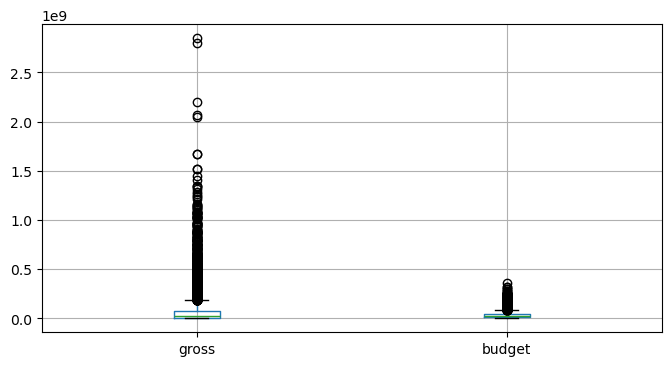

In [38]:
#Checking the outliers of the two categories Gross and Budget 
frame.boxplot(column = ["gross", "budget" ])
plt.show ()


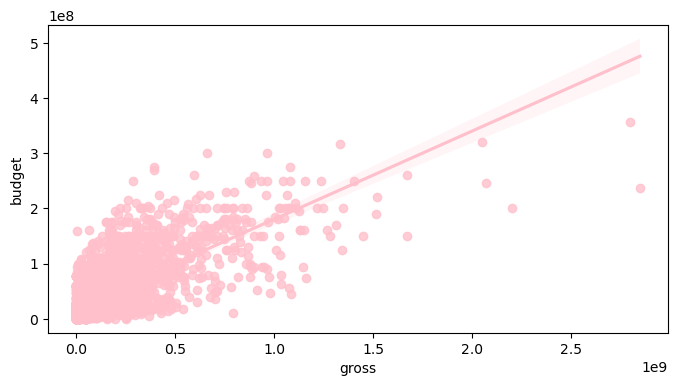

In [40]:
#Using seaborn regplot to see the correlation between the two variables gross and budget 
sns.regplot (x = "gross", y = "budget", data = frame, color = 'pink')
plt.show ()

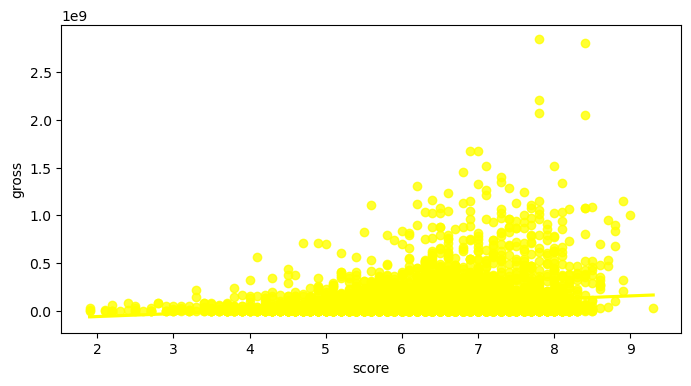

In [41]:
 #Using seaborn regplot to see the correlation between the two variables gross and score 
sns.regplot (x = "score", y = "gross", data = frame, color = 'yellow')
plt.show ()

In [42]:
#Check the correlation with all the numeric vars using the default method "Pearson" - standard linear correlation coefficient
corr = frame.corr (numeric_only = True)
print (corr)

         year  score  votes  runtime  gross  budget  profit  ROI(%)
year        1      0      0        0      0       0       0       0
score       0      1      0        0      0       0       0      -0
votes       0      0      1        0      1       0       1       0
runtime     0      0      0        1      0       0       0      -0
gross       0      0      1        0      1       1       1       0
budget      0      0      0        0      1       1       1      -0
profit      0      0      1        0      1       1       1       0
ROI(%)      0     -0      0       -0      0      -0       0       1


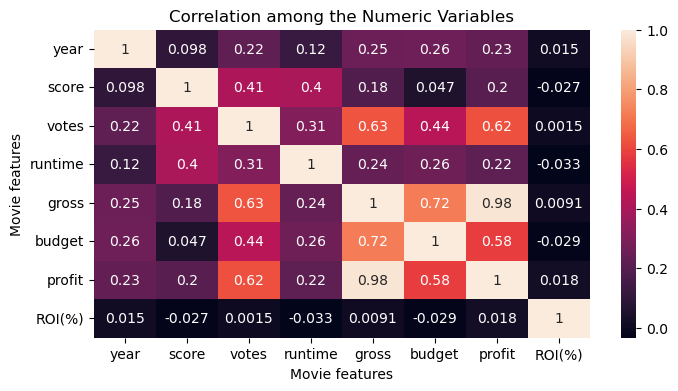

In [43]:
sns.heatmap (corr, annot = True)
plt.title ("Correlation among the Numeric Variables")
plt.xlabel ("Movie features")
plt.ylabel ("Movie features")
plt.show ()

In [44]:
#Stack the values into "group"
stacked_corr = corr.stack()

In [45]:
#Sort the correlation pair descendingly, also get rid of the correlation of the same variables

stacked_corr.sort_values (ascending = False)[6:].drop_duplicates()


votes    votes      1
profit   gross      1
gross    budget     1
         votes      1
profit   votes      1
         budget     1
votes    budget     0
         score      0
score    runtime    0
runtime  votes      0
budget   year       0
         runtime    0
year     gross      0
gross    runtime    0
profit   year       0
year     votes      0
runtime  profit     0
score    profit     0
gross    score      0
runtime  year       0
year     score      0
score    budget     0
ROI(%)   profit     0
year     ROI(%)     0
gross    ROI(%)     0
ROI(%)   votes      0
score    ROI(%)    -0
ROI(%)   budget    -0
runtime  ROI(%)    -0
dtype: float64

In [46]:
#Now look into the gross by each country average per movie, look at top 10 for now
gross_by_country = frame.groupby ("country")["gross"].mean().fillna (0).sort_values (ascending = False) 


print (gross_by_country[:10])

country
Malta                  352,794,081
New Zealand            258,870,387
China                  219,735,745
Finland                169,193,791
United States           89,524,173
United Arab Emirates    88,586,133
South Africa            77,293,178
Lebanon                 64,417,003
United Kingdom          61,194,764
Japan                   53,462,542
Name: gross, dtype: float64


In [47]:
gross_expense_by_year = frame.groupby("year")[["gross", "budget"]].sum()
# print (gross_expense_by_year.sort_values ("gross", ascending = False).head(10))
 

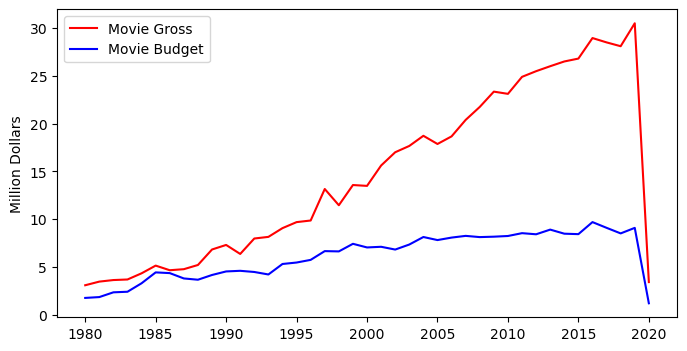

In [48]:
plt.plot(gross_expense_by_year["gross"]/1e9, label = "Movie Gross", color = "red")
plt.plot(gross_expense_by_year["budget"]/1e9, label = "Movie Budget", color = "blue")
plt.ylabel("Million Dollars")
plt.legend()
plt.show ()

In [49]:
#Check whether we need to normalise the genre 
frame["genre"].unique()

array(['Drama', 'Adventure', 'Action', 'Comedy', 'Horror', 'Biography',
       'Crime', 'Fantasy', 'Family', 'Sci-Fi', 'Animation', 'Romance',
       'Music', 'Western', 'Thriller', 'History', 'Mystery', 'Sport',
       'Musical'], dtype=object)

In [51]:
#Check whether we need to normalise the genre 
frame["rating"].unique()

#Notice that these rating are mixed from different sources and bases so will proceed to normalising it 

array(['R', 'PG', 'G', nan, 'Not Rated', 'NC-17', 'Approved', 'TV-PG',
       'PG-13', 'Unrated', 'X', 'TV-MA', 'TV-14'], dtype=object)

In [52]:
#Standardize the ratings 
rating_map = {
    "TV-PG": "PG",
    "TV-14": "PG-13",
    "TV-MA": "R",
    "X": "NC-17",
    "Approved": "G",
    "Unrated": "Not Rated"
}

frame["rating_cleaned"] = frame["rating"].replace(rating_map)
frame["rating_cleaned"].fillna("Not Rated").unique()
 

array(['R', 'PG', 'G', 'Not Rated', 'NC-17', 'PG-13'], dtype=object)

In [53]:
frame ["rating"] = frame["rating_cleaned"]
frame["rating"] = frame["rating"].fillna ("Not Rated")

In [54]:
#Reconfirm the rating column 
frame["rating"].unique()

array(['R', 'PG', 'G', 'Not Rated', 'NC-17', 'PG-13'], dtype=object)

In [55]:
#Adding the rating def for non-industry audience 
rating_def = {
    "G": "All audiences",
    "PG": "Parental guidance",
    "PG-13": "Parents cautioned (under 13)",
    "R": "Under 17 with adult",
    "NC-17": "Adults only",
    "Not Rated": "No official rating"}

frame["rating_def"] = frame["rating"].map(rating_def)
frame

,name,rating,genre,year,score,votes,director,writer,star,country,company,runtime,released_country,gross,budget,profit,ROI(%),loss/gain,rating_cleaned,rating_def
0,The Shining,R,Drama,1980,8,"927,000",Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146,United States,"46,998,772","19,000,000","27,998,772",147,Gain,R,Under 17 with adult
1,The Blue Lagoon,R,Adventure,1980,6,"65,000",Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104,United States,"58,853,106","4,500,000","54,353,106","1,208",Gain,R,Under 17 with adult
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,9,"1,200,000",Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124,United States,"538,375,067","18,000,000","520,375,067","2,891",Gain,PG,Parental guidance
3,Airplane!,PG,Comedy,1980,8,"221,000",Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88,United States,"83,453,539","3,500,000","79,953,539","2,284",Gain,PG,Parental guidance
4,Caddyshack,R,Comedy,1980,7,"108,000",Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98,United States,"39,846,344","6,000,000","33,846,344",564,Gain,R,Under 17 with adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7661,More to Life,Not Rated,Drama,2020,3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,NaN,90,United States,"47,950,515","7,000","47,943,515","684,907",Gain,NaN,No official rating
7662,Dream Round,Not Rated,Comedy,2020,5,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,Cactus Blue Entertainment,90,United States,"48,299,491","23,510,451","24,789,040",105,Gain,NaN,No official rating
7663,Saving Mbango,Not Rated,Drama,2020,6,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,Embi Productions,NaN,Cameroon,"50,918,683","58,750","50,859,933","86,570",Gain,NaN,No official rating
7664,It's Just Us,Not Rated,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,NaN,120,United States,"47,950,515","15,000","47,935,515","319,570",Gain,NaN,No official rating


In [56]:
#Drop unnecessary columns 
frame = frame.drop(columns = "rating")
frame = frame.rename(columns = {"rating_cleaned" : "rating" })
frame 

,name,genre,year,score,votes,director,writer,star,country,company,runtime,released_country,gross,budget,profit,ROI(%),loss/gain,rating,rating_def
0,The Shining,Drama,1980,8,"927,000",Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146,United States,"46,998,772","19,000,000","27,998,772",147,Gain,R,Under 17 with adult
1,The Blue Lagoon,Adventure,1980,6,"65,000",Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104,United States,"58,853,106","4,500,000","54,353,106","1,208",Gain,R,Under 17 with adult
2,Star Wars: Episode V - The Empire Strikes Back,Action,1980,9,"1,200,000",Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124,United States,"538,375,067","18,000,000","520,375,067","2,891",Gain,PG,Parental guidance
3,Airplane!,Comedy,1980,8,"221,000",Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88,United States,"83,453,539","3,500,000","79,953,539","2,284",Gain,PG,Parental guidance
4,Caddyshack,Comedy,1980,7,"108,000",Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98,United States,"39,846,344","6,000,000","33,846,344",564,Gain,R,Under 17 with adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7661,More to Life,Drama,2020,3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,NaN,90,United States,"47,950,515","7,000","47,943,515","684,907",Gain,NaN,No official rating
7662,Dream Round,Comedy,2020,5,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,Cactus Blue Entertainment,90,United States,"48,299,491","23,510,451","24,789,040",105,Gain,NaN,No official rating
7663,Saving Mbango,Drama,2020,6,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,Embi Productions,NaN,Cameroon,"50,918,683","58,750","50,859,933","86,570",Gain,NaN,No official rating
7664,It's Just Us,Drama,2020,NaN,NaN,James Randall,James Randall,Christina Roz,United States,NaN,120,United States,"47,950,515","15,000","47,935,515","319,570",Gain,NaN,No official rating


In [58]:
#Convert to csv on device ready for further visualisation 
frame.to_csv(r'/Users/sarahnguyen313/Downloads/Final_movie_cleaned.csv', index = False)